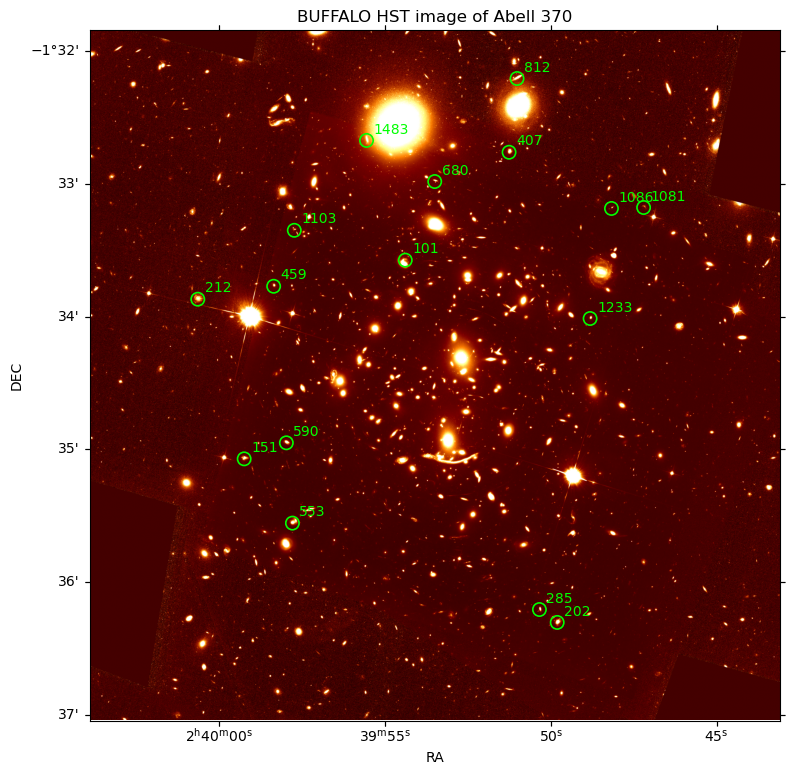

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Circle

# ----------------------------------------------------
# Input files
# ----------------------------------------------------
fits_file = "BUFFALO/HSTcutout_full_cluster.fits"
cat_file  = "catalogs/ChMA370_entire_list.cat"

# ----------------------------------------------------
# Load FITS image and WCS
# ----------------------------------------------------
with fits.open(fits_file) as hdul:
    data = hdul[0].data
    header = hdul[0].header

wcs = WCS(header)

# ----------------------------------------------------
# Load catalog
# ----------------------------------------------------
# This works for whitespace- or tab-separated tables
cat = Table.read(cat_file, format="ascii")

ids = cat["Id"]
ra  = cat["RA"] * u.deg
dec = cat["DEC"] * u.deg

# ----------------------------------------------------
# Convert RA/DEC to pixel coordinates
# ----------------------------------------------------
coords = SkyCoord(ra=ra, dec=dec, frame="icrs")
xpix, ypix = wcs.world_to_pixel(coords)

# ----------------------------------------------------
# Plot image with WCS projection
# ----------------------------------------------------
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

# Display image
im = ax.imshow(
    data,
    origin="lower",
    cmap="afmhot",
    vmin=np.nanpercentile(data, 1),
    vmax=np.nanpercentile(data, 99)
)

# ----------------------------------------------------
# Overplot catalog objects
# ----------------------------------------------------
circle_radius = 50  # pixels

for i in range(len(ids)):
    # Draw circle
    circ = Circle(
        (xpix[i], ypix[i]),
        radius=circle_radius,
        edgecolor="lime",
        facecolor="none",
        linewidth=1.2
    )
    ax.add_patch(circ)

    # Label with ID
    ax.text(
        xpix[i] + circle_radius + 2,
        ypix[i] + circle_radius + 2,
        str(ids[i]),
        color="lime",
        fontsize=10
    )

# ----------------------------------------------------
# Axes labels and formatting
# ----------------------------------------------------
ax.set_xlabel("RA")
ax.set_ylabel("DEC")
ax.set_title("BUFFALO HST image of Abell 370")

#plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Flux")

plt.tight_layout()
plt.savefig("fullClusterHST_withCat.png", dpi=300, bbox_inches="tight")
plt.show()
